In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import pandas as pd
import yfinance as yf
import time
from helpers import filter_daily_volume, drop_nan_days, get_all_us_tickers, get_data, filter_tickers
import numpy as np
import matplotlib.pyplot as plt
from TradingSim import TradingSim

In [3]:
tmp = pd.read_parquet("AllUSData-20100101-20260303.parquet")

In [4]:
full_df = tmp.copy()
qqq_spy = yf.download(["QQQ", "SPY"], start="2010-01-01", end="2026-03-03")
full_df = pd.concat([full_df, qqq_spy], axis=1)

C:\Users\sasso\AppData\Local\Temp\ipykernel_151196\3354087779.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  qqq_spy = yf.download(["QQQ", "SPY"], start="2010-01-01", end="2026-03-03")
c:\Users\sasso\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  2 of 2 completed


In [5]:
def get_steady(df, year):
	df = full_df[full_df.index.year == year]

	rolling_data = df["Close"].pct_change().rolling(window=30).mean() * 100
	rolling_data.columns = pd.MultiIndex.from_product([["rollingChange"], rolling_data.columns])
	df = df.join(rolling_data)

	df = filter_daily_volume(df, 2000000, True)
	df = drop_nan_days(df, "Close", 2)

	stats_df = pd.DataFrame(index=df.columns.get_level_values(1).unique().tolist())
	close = df["Close"]
	pct_change = ((close.iloc[-1] - close.iloc[0]) / close.iloc[0]) * 100
	daily_returns = close.pct_change()
	volatility = daily_returns.std() * np.sqrt(252) * 100 
	steady_score = pct_change / volatility

	nan_days = close.isna()

	stats_df["TotalReturn %"] = pct_change
	stats_df["Volatility %"] = volatility
	stats_df["SteadyScore"] = steady_score
	stats_df["PositiveDays %"] = (daily_returns > 0).mean() * 100

	# max drawdown - Distance between lowest and peak
	rolling_max = close.cummax()
	daily_drawdown = (close - rolling_max) / rolling_max  # Distance from peak
	stats_df["MaxDrawdown %"] = daily_drawdown.min() * 100  # % distance from worst drop

	sma_50 = df["Close"].rolling(window=50).mean().iloc[-1]
	stats_df["DistFromSMA50 %"] = ((close.iloc[-1] / sma_50) - 1) * 100

	median_vol_30d = df["Volume"].rolling(window=30).median().iloc[-1]
	stats_df["VolumeSurgeRatio"] = df["Volume"].iloc[-1] / median_vol_30d

	daily_range = df["High"] - df["Low"]
	atr_14 = daily_range.rolling(window=14).mean().iloc[-1]
	stats_df["ATR %"] = (atr_14 / df["Close"].iloc[-1]) * 100
	score_df = stats_df.copy()
	score_df["TotalReturn"] = score_df["TotalReturn %"].rank(pct=True) * 100
	score_df["Volatility %"] = score_df["Volatility %"].rank(pct=True, ascending=False) * 100
	score_df["SteadyScore"] = score_df["SteadyScore"].rank(pct=True) * 100
	score_df["PositiveDays"] = score_df["PositiveDays %"].rank(pct=True) * 100
	score_df["MaxDrawdown %"] = score_df["MaxDrawdown %"].rank(pct=True) * 100
	score_df["DistFromSMA50 %"] = score_df["DistFromSMA50 %"].rank(pct=True) * 100
	score_df["VolumeSurgeRatio"] = score_df["VolumeSurgeRatio"].rank(pct=True) * 100
	score_df["ATR %"] = score_df["ATR %"].rank(pct=True, ascending=False) * 100

	score_df.rename(columns={"Volatility %": "Volatility", "MaxDrawdown %": "MaxDrawdown", "DistFromSMA50 %": "DistFromSMA50", "ATR %": "ATR"}, inplace=True)
	
	# filter_column(score_df, "TotalReturn %", 40)

	weights = {
		"TotalReturn": 4,
		"Volatility": 3,
		"SteadyScore": 9,
		"PositiveDays": 3,
		"MaxDrawdown": 8,
		"DistFromSMA50": 2,
		"VolumeSurgeRatio": 1,
		"ATR": 5
	}
	score_df["FinalScore"] = (
		(score_df["TotalReturn"] * weights["TotalReturn"]) +
		(score_df["Volatility"] * weights["Volatility"]) +
		(score_df["SteadyScore"] * weights["SteadyScore"]) +
		(score_df["PositiveDays"] * weights["PositiveDays"]) +
		(score_df["MaxDrawdown"] * weights["MaxDrawdown"]) +
		(score_df["DistFromSMA50"] * weights["DistFromSMA50"]) +
		(score_df["VolumeSurgeRatio"] * weights["VolumeSurgeRatio"]) +
		(score_df["ATR"] * weights["ATR"])
	)
	score_df["FinalScore"] = score_df["FinalScore"].rank(pct=True) * 100
	score_df.dropna(subset=["FinalScore"], inplace=True)
	score_df["Rank"] = score_df["FinalScore"].rank(ascending=False, method="min").astype(int)
	return score_df

def get_returns(df, entry, tickers):
	sim = TradingSim(df)
	return sim.optimizer_exit_after(entry, tickers)

def get_plot(returns, avg_ret=None, plot_size=80):
	tickers = returns.columns
	line_styles = ['--' if ticker in ['QQQ', 'SPY'] else '-' for ticker in tickers]
	returns[returns.index < plot_size].plot(figsize=(12, 6), style=line_styles)
	if avg_ret:
		plt.annotate(f"{round(avg_ret[1], 2)}%", xy=(avg_ret[0] + 0.5, avg_ret[1] + 0.5), color='indigo', fontweight="bold")
		plt.axvline(x=avg_ret[0], linestyle=":", color="indigo")
		plt.axhline(y=avg_ret[1], linestyle=":", color="indigo")
	plt.grid(True, linestyle="--", alpha=0.7)


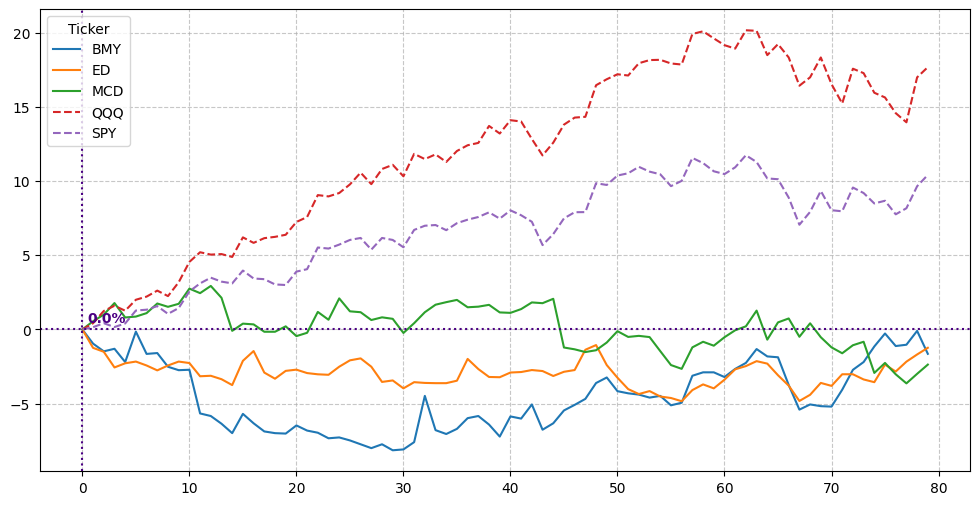

In [20]:
# exit_after = 40
year = 2011
look_after = 80  # After that algorithm is shit and we won't listen to it

# for year in range(2010, 2025)

entry = f"{year + 1}-01-01"
score_df = get_steady(full_df, year).sort_values("FinalScore", ascending=False)
top_tickers = score_df.head(3)
returns, returns_mean = get_returns(full_df, entry, top_tickers.index.to_list() + ["QQQ", "SPY"])
best_exit_idx = returns_mean.head(look_after).sort_values(ascending=False).index[0]
best_exit_val =  returns_mean.head(look_after).sort_values(ascending=False).values[0]
# avg_ret = returns_mean.iloc[best_exit]
# returns_mean.head(80).plot()
get_plot(returns, (best_exit_idx, best_exit_val))

In [10]:
returns_mean.head(80).sort_values(ascending=False).head(1).values[0]

np.float64(16.89006203246531)